In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = fetch_california_housing()

X = data.data   # features
y = data.target # house prices

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = Sequential()

# Input + Hidden layers
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))

# Output layer (1 neuron for regression)
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9935 - mae: 0.6775 - val_loss: 0.4886 - val_mae: 0.5176
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4106 - mae: 0.4605 - val_loss: 0.4150 - val_mae: 0.4562
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3768 - mae: 0.4399 - val_loss: 0.3977 - val_mae: 0.4546
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3596 - mae: 0.4270 - val_loss: 0.3950 - val_mae: 0.4321
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3499 - mae: 0.4183 - val_loss: 0.3703 - val_mae: 0.4220
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3427 - mae: 0.4098 - val_loss: 0.3563 - val_mae: 0.4103
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3291 - mae: 0.4027 - val_loss: 0.3544 - val_mae: 0.4100
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3165 - mae: 0.3954 - val_loss: 0.3428 - val_mae: 0.4046
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [8]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2822 - mae: 0.3582
Test Loss: 0.28222766518592834
Test MAE: 0.35820233821868896


In [11]:
for i in range(5):
    print(f"Predicted: {y_pred[i][0]:.2f}, Actual: {y_test[i]:.2f}")

Predicted: 0.41, Actual: 0.48
Predicted: 1.05, Actual: 0.46
Predicted: 4.88, Actual: 5.00
Predicted: 2.53, Actual: 2.19
Predicted: 2.83, Actual: 2.78


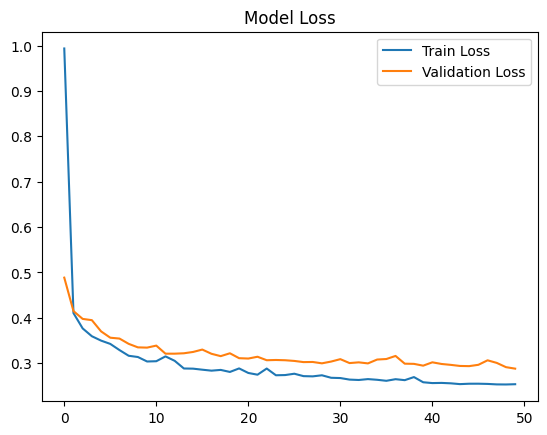

In [12]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()